In [2]:
!pip install ultralytics
!pip install roboflow
!pip install numpy==1.26.4
!pip install torch==2.3.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 81.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [20]:
# Importar bibliotecas a usar y deshabilitar WanDB
import os
import yaml
import torch
import wandb
import shutil
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from roboflow import Roboflow
from ultralytics import YOLO

os.environ['WANDB_DISABLED'] = 'true'
model = YOLO("yolo11m.pt")

# Descargar base de datos
rf = Roboflow(api_key="SfwF0Ui5TtR8rrhcxaSm")
project = rf.workspace("test-pdi").project("taco-trash-annotations-in-context-jbgaw")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to TACO:-Trash-Annotations-in-Context-Dataset-1 in yolov11:: 100%|██████████| 3010/3010 [00:00<00:00, 7887.26it/s]


In [21]:
!mv TACO:-Trash-Annotations-in-Context-Dataset-1 ./datasets
!ls -la ./datasets

total 36
drwxr-xr-x 6 root root 4096 Dec 11 20:32 .
drwxr-xr-x 4 root root 4096 Dec 11 20:32 ..
-rw-r--r-- 1 root root 1311 Dec 11 20:27 data.yaml
-rw-r--r-- 1 root root 1489 Dec 11 20:27 README.dataset.txt
-rw-r--r-- 1 root root  954 Dec 11 20:27 README.roboflow.txt
drwxr-xr-x 5 root root 4096 Dec 11 20:32 TACO:-Trash-Annotations-in-Context-Dataset-1
drwxr-xr-x 4 root root 4096 Dec 11 20:27 test
drwxr-xr-x 4 root root 4096 Dec 11 20:27 train
drwxr-xr-x 4 root root 4096 Dec 11 20:27 valid


In [22]:
# Creación del directorio de las partes de la base de datos
data = {
    'path': './TACO:-Trash-Annotations-in-Context-Dataset-1',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'names': {
        0: "Aerosol", 1: "Aluminium blister pack", 2: "Aluminium foil", 3: "Battery", 4: "Broken glass", 5: "Carded blister pack",
        6: "Cigarette", 7: "Clear plastic bottle", 8: "Corrugated carton", 9: "Crisp packet", 10: "Disposable food container", 11: "Disposable plastic cup",
        12: "Drink can", 13: "Drink carton", 14: "Egg carton", 15: "Foam cup", 16: "Foam food container", 17: "Food Can",
        18: "Food waste", 19: "Garbage bag", 20: "Glass bottle", 21: "Glass cup", 22: "Glass jar", 23: "Magazine paper",
        24: "Meal carton", 25: "Metal bottle cap", 26: "Metal lid", 27: "Normal paper", 28: "Other carton", 29: "Other plastic",
        30: "Other plastic bottle", 31: "Other plastic container", 32: "Other plastic cup",33: "Other plastic wrapper", 34: "Paper bag", 35: "Paper cup",
        36: "Paper straw", 37: "Pizza box", 38: "Plastic bottle cap",
        39: "Plastic film", 40: "Plastic glooves", 41: "Plastic lid", 42: "Plastic straw", 43: "Plastic utensils", 44: "Polypropylene bag",
        45: "Pop tab", 46: "Rope - strings", 47: "Scrap metal", 48: "Shoe", 49: "Single-use carrier bag", 50: "Six pack rings",
        51: "Spread tub", 52: "Squeezable tube", 53: "Styrofoam piece", 54: "Tissues", 55: "Toilet tube", 56: "Tupperware",
        57: "Unlabeled litter", 58: "Wrapping paper"
    },


    'roboflow': {
        'license': 'CC BY 4.0',
        'project': 'taco-trash-annotations-in-context-jbgaw',
        'url': 'https://app.roboflow.com/test-pdi/taco-trash-annotations-in-context-jbgaw/1',
        'version': 1,
        'workspace': 'test-pdi'}
}

# Especificar el directorio del archivo
file_path = './datasets/TACO:-Trash-Annotations-in-Context-Dataset-1/data.yaml'

# Escribir la información sobre el archivo YAML
with open(file_path, 'w') as yaml_file:
    yaml.dump(data, yaml_file, default_flow_style=False)

In [23]:
from ultralytics import YOLO

# Cargar modelo
model = YOLO("yolo11m.pt")
results = model.train(
    data="./datasets/TACO:-Trash-Annotations-in-Context-Dataset-1/data.yaml",
    epochs=30,
    imgsz=128,
    batch=8,
    plots=True,
    device=[0,1]
)

Ultralytics 8.3.236 🚀 Python-3.11.13 torch-2.3.0+cu118 CUDA:0 (Tesla T4, 15095MiB)
                                                       CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/TACO:-Trash-Annotations-in-Context-Dataset-1/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=F

In [31]:
ls runs/detect

train/  val/


In [28]:
# Validar el modelo entrenado

from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Cargar el modelo entrenado
model = YOLO('./runs/detect/train/weights/best.pt')

# Validación
validation_results = model.val(
    data='./datasets/TACO:-Trash-Annotations-in-Context-Dataset-1/data.yaml',
    imgsz=640,
    batch=16,
    conf=0.25,
    iou=0.6,
    device='cpu'
)



Ultralytics 8.3.236 🚀 Python-3.11.13 torch-2.3.0+cu118 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11m summary (fused): 125 layers, 20,075,521 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 753.0±149.7 MB/s, size: 28.6 KB)
val: Scanning /kaggle/working/datasets/TACO:-Trash-Annotations-in-Context-Dataset-1/valid/labels.cache... 299 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 299/299 357.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 17.6s/it 5:3517.8s


invalid value encountered in less
invalid value encountered in less


                   all        299       1009     0.0279     0.0488     0.0233      0.017
               Aerosol          1          1          0          0          0          0
Aluminium blister pack          3          3          0          0          0          0
        Aluminium foil         10         22      0.133     0.0909      0.123     0.0957
               Battery          1          1          0          0          0          0
          Broken glass          4         43          0          0          0          0
             Cigarette         44        148          0          0          0          0
  Clear plastic bottle         47         57     0.0977      0.279     0.0904     0.0616
     Corrugated carton          4          7          0          0          0          0
          Crisp packet          5          5          0          0          0          0
Disposable food container          3          3          0          0          0          0
Disposable plastic

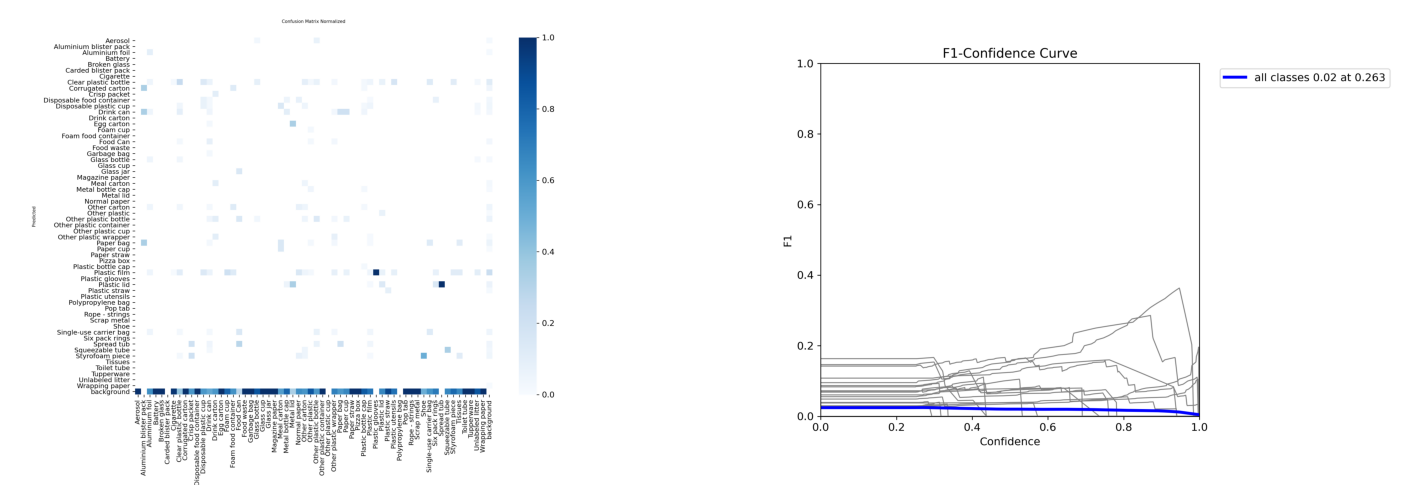

In [32]:
cm = mpimg.imread("runs/detect/val/confusion_matrix_normalized.png")
f1 = mpimg.imread("runs/detect/val/BoxF1_curve.png")

fig, axis = plt.subplots(1, 2, figsize=(18, 8))
axis[0].imshow(cm); axis[0].axis('off')
axis[1].imshow(f1); axis[1].axis('off')
plt.show()

In [33]:
model.export(format='torchscript',dynamic=True)

Ultralytics 8.3.236 🚀 Python-3.11.13 torch-2.3.0+cu118 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 128, 128) BCHW and output shape(s) (1, 63, 336) (38.7 MB)

TorchScript: starting export with torch 2.3.0+cu118...
TorchScript: export success ✅ 2.7s, saved as 'runs/detect/train/weights/best.torchscript' (77.2 MB)

Export complete (2.9s)
Results saved to /kaggle/working/runs/detect/train/weights
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.torchscript imgsz=128  
Validate:        yolo val task=detect model=runs/detect/train/weights/best.torchscript imgsz=128 data=./datasets/TACO:-Trash-Annotations-in-Context-Dataset-1/data.yaml  
Visualize:       https://netron.app


'runs/detect/train/weights/best.torchscript'

Ultralytics 8.3.236 🚀 Python-3.11.13 torch-2.3.0+cu118 CPU (Intel Xeon CPU @ 2.00GHz)
Loading ./runs/detect/train/weights/best.torchscript for TorchScript inference...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 947.0±166.6 MB/s, size: 26.5 KB)
val: Scanning /kaggle/working/datasets/TACO:-Trash-Annotations-in-Context-Dataset-1/valid/labels.cache... 299 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 299/299 525.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 299/299 13.5it/s 22.1s<0.1s


invalid value encountered in less
invalid value encountered in less


                   all        299       1009      0.104     0.0206     0.0618     0.0437
               Aerosol          1          1          0          0          0          0
Aluminium blister pack          3          3          0          0          0          0
        Aluminium foil         10         22        0.8      0.182      0.473      0.334
               Battery          1          1          0          0          0          0
          Broken glass          4         43          0          0          0          0
             Cigarette         44        148          0          0          0          0
  Clear plastic bottle         47         57          1     0.0526      0.526      0.492
     Corrugated carton          4          7      0.333      0.286       0.32      0.203
          Crisp packet          5          5          0          0          0          0
Disposable food container          3          3          0          0          0          0
Disposable plastic

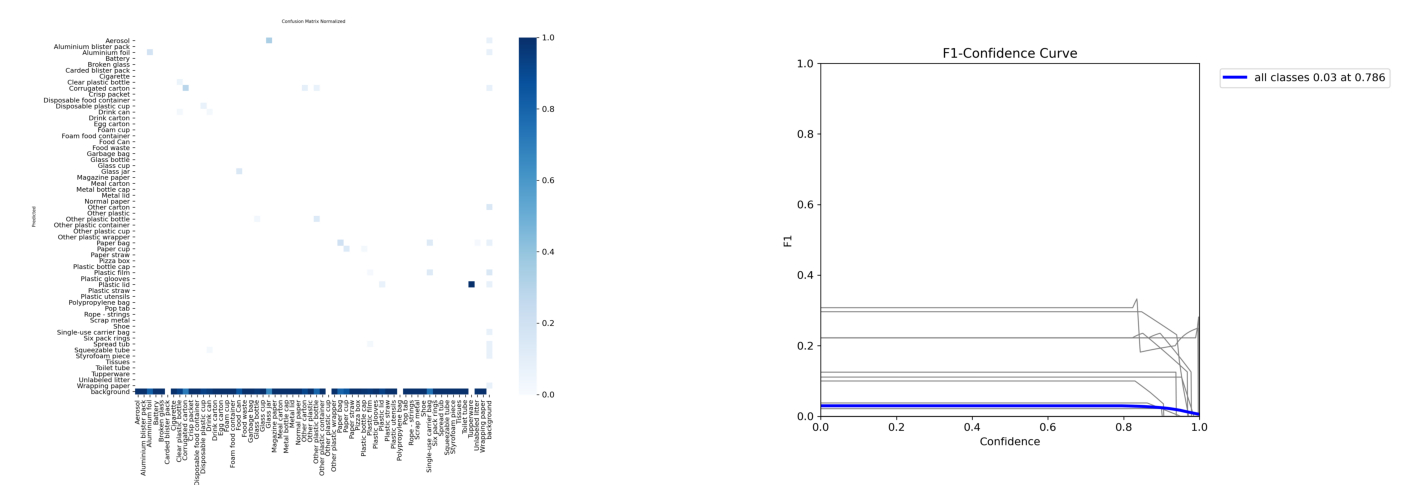

In [35]:
ts_wrapped_model = YOLO('./runs/detect/train/weights/best.torchscript')
# Realizar validación
validation_results = ts_wrapped_model.val(data='./datasets/TACO:-Trash-Annotations-in-Context-Dataset-1/data.yaml',
                               imgsz=128,
                               batch=1,
                               conf=0.8,
                               iou=0.6,
                               device='cpu')

# Cargar la imagen
image = mpimg.imread("./runs/detect/val2/confusion_matrix_normalized.png")
image_1 = mpimg.imread("./runs/detect/val2/BoxF1_curve.png")

# Mostrar la matriz de confusión imagen
fig, axis = plt.subplots(1,2,figsize=(18,8))
axis[0].imshow(image)
axis[0].axis('off')
axis[1].imshow(image_1)
axis[1].axis('off')
plt.show()

In [36]:
import glob
DATASET_YAML = "./datasets/TACO:-Trash-Annotations-in-Context-Dataset-1/data.yaml"

# Rutas generadas por YOLO
ORIG_MODEL_PATH = "runs/detect/train/weights/best.pt"
TS_MODEL_PATH   = "runs/detect/train/weights/best.torchscript"

print("Validando modelo ORIGINAL (.pt)...")
orig_model = YOLO(ORIG_MODEL_PATH)

orig_results = orig_model.val(data=DATASET_YAML, imgsz=128, batch=1,conf=0.8, iou=0.6, device='cpu')

# ============================================================
print("Validando modelo TORCHSCRIPT...")
ts_model = YOLO(TS_MODEL_PATH)

ts_results = ts_model.val(data=DATASET_YAML, imgsz=128, batch=1, conf=0.8, iou=0.6,device='cpu')

Validando modelo ORIGINAL (.pt)...
Ultralytics 8.3.236 🚀 Python-3.11.13 torch-2.3.0+cu118 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11m summary (fused): 125 layers, 20,075,521 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 770.6±190.1 MB/s, size: 30.7 KB)
val: Scanning /kaggle/working/datasets/TACO:-Trash-Annotations-in-Context-Dataset-1/valid/labels.cache... 299 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 299/299 338.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 299/299 11.4it/s 26.3s0.2ss


invalid value encountered in less
invalid value encountered in less


                   all        299       1009      0.104     0.0206     0.0618     0.0437
               Aerosol          1          1          0          0          0          0
Aluminium blister pack          3          3          0          0          0          0
        Aluminium foil         10         22        0.8      0.182      0.473      0.334
               Battery          1          1          0          0          0          0
          Broken glass          4         43          0          0          0          0
             Cigarette         44        148          0          0          0          0
  Clear plastic bottle         47         57          1     0.0526      0.526      0.492
     Corrugated carton          4          7      0.333      0.286       0.32      0.203
          Crisp packet          5          5          0          0          0          0
Disposable food container          3          3          0          0          0          0
Disposable plastic

invalid value encountered in less
invalid value encountered in less


                   all        299       1009      0.104     0.0206     0.0618     0.0437
               Aerosol          1          1          0          0          0          0
Aluminium blister pack          3          3          0          0          0          0
        Aluminium foil         10         22        0.8      0.182      0.473      0.334
               Battery          1          1          0          0          0          0
          Broken glass          4         43          0          0          0          0
             Cigarette         44        148          0          0          0          0
  Clear plastic bottle         47         57          1     0.0526      0.526      0.492
     Corrugated carton          4          7      0.333      0.286       0.32      0.203
          Crisp packet          5          5          0          0          0          0
Disposable food container          3          3          0          0          0          0
Disposable plastic

In [45]:
import torch
import cv2

# Cargar modelo .pt como PyTorch nn.Module
from ultralytics import YOLO

pt_model = YOLO("runs/detect/train/weights/best.pt")
pt_model.eval()

# Cargar modelo TorchScript
ts_model = torch.jit.load("runs/detect/train/weights/best.torchscript")
ts_model.eval()
def cargar_imagen_tensor(ruta):
    img = cv2.imread(ruta)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (640, 640))
    img = img.transpose(2, 0, 1)  # HWC → CHW
    img = img / 255.0
    img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
    return img
import time

def medir_tiempo(modelo, tensor):
    inicio = time.time()
    with torch.no_grad():
        _ = modelo(tensor)
    fin = time.time()
    return (fin - inicio) * 1000  # ms
IMAGEN = "runs/detect/train/train_batch2.jpg"
tensor_img = cargar_imagen_tensor(IMAGEN)

t_pt = medir_tiempo(pt_model, tensor_img)
t_ts = medir_tiempo(ts_model, tensor_img)

print(f"Inferencia modelo .pt:        {t_pt:.2f} ms")
print(f"Inferencia TorchScript .ts:  {t_ts:.2f} ms")



0: 640x640 2 Disposable food containers, 2 Drink cans, 1 Metal bottle cap, 2 Other plastic bottles, 1 Other plastic wrapper, 2 Pop tabs, 1 Styrofoam piece, 38.9ms
Speed: 1.3ms preprocess, 38.9ms inference, 3.9ms postprocess per image at shape (1, 3, 640, 640)
Inferencia modelo .pt:        266.51 ms
Inferencia TorchScript .ts:  988.36 ms


In [42]:
ls runs/detect/train

args.yaml                        results.csv          val_batch0_labels.jpg
BoxF1_curve.png                  results.png          val_batch0_pred.jpg
BoxP_curve.png                   train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png                  train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png                   train_batch2640.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch2641.jpg  val_batch2_pred.jpg
confusion_matrix.png             train_batch2642.jpg  weights/
labels.jpg                       train_batch2.jpg


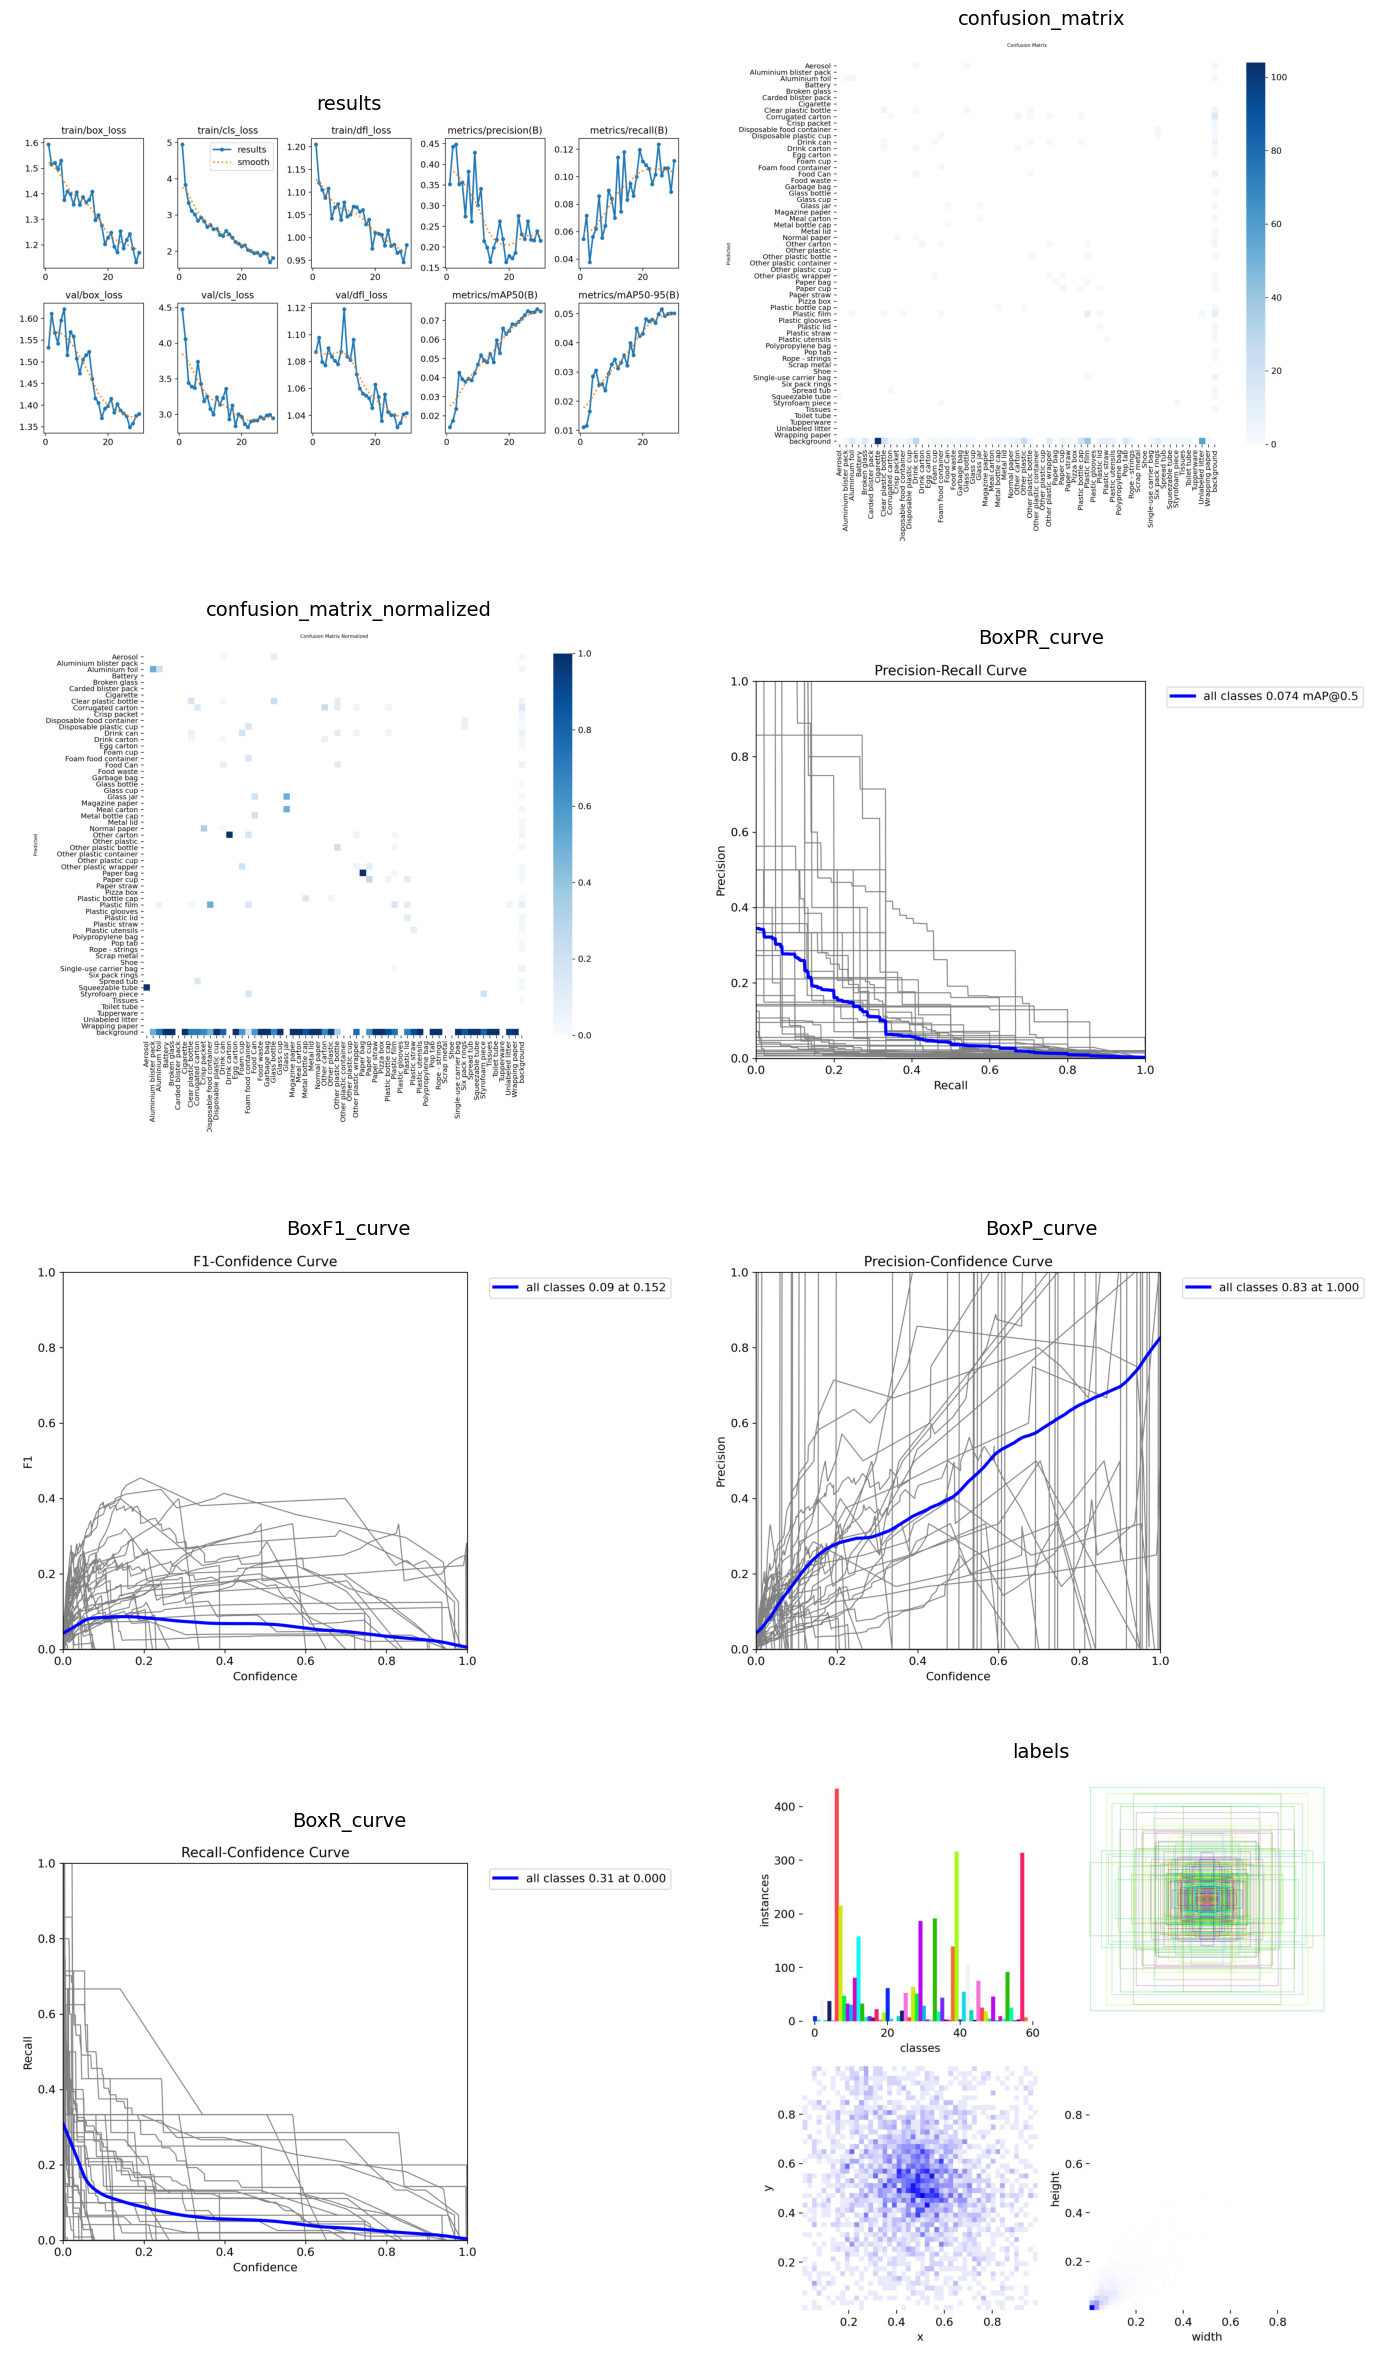

In [47]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Carpeta donde YOLO guardó los resultados
TRAIN_DIR = "runs/detect/train"

# Lista de imágenes a mostrar
imagenes = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "labels.jpg"
]

# Filtrar solo las que realmente existen
imagenes_existentes = [img for img in imagenes if os.path.exists(os.path.join(TRAIN_DIR, img))]

# Mostrar
n = len(imagenes_existentes)
cols = 2
rows = (n + 1) // cols

plt.figure(figsize=(14, 6 * rows))

for i, img_name in enumerate(imagenes_existentes, 1):
    img_path = os.path.join(TRAIN_DIR, img_name)
    img = Image.open(img_path)

    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name.replace(".png", "").replace(".jpg", ""), fontsize=14)

plt.tight_layout()
plt.show()


In [51]:
ls runs/detect/train/weights


best.pt  best.torchscript  last.pt
